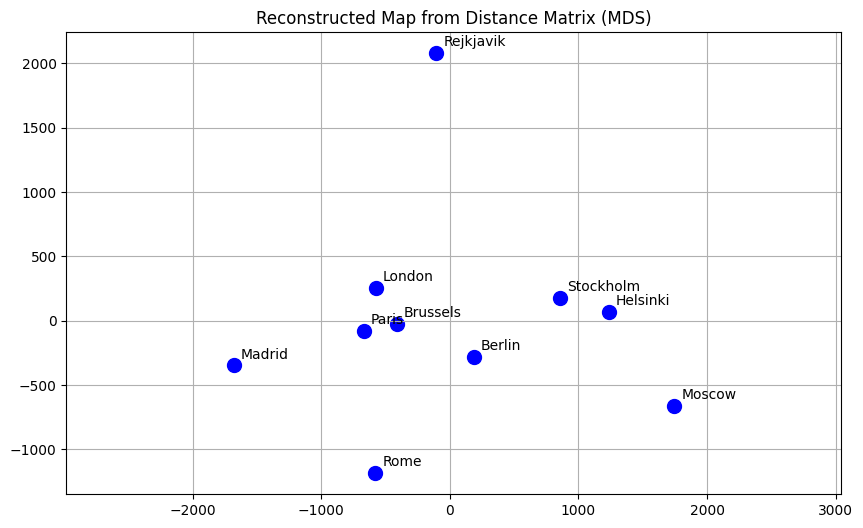

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import euclidean_distances

def cmdscale(D_squared, k=2):
    """ implement cMDS from lecture"""
    n = D_squared.shape[0]
    
    # calc centering matrix H
    H = np.eye(n) - (1/n) * np.ones((n, n))
    
    # calce B = -1/2 * H * D_squared * H
    B = -0.5 * H @ D_squared @ H
    
    # spectral decomposition
    # note: np.linalg.eigh returns eigenvalues in ascending order
    evals, evecs = np.linalg.eigh(B)
    
    # sort
    idx = np.argsort(evals)[::-1]
    evals = evals[idx]
    evecs = evecs[:, idx]
    
    # 4. zero negative eigenvalues (for non-Euclidean noise)
    evals_pos = np.maximum(evals, 0)
    
    # calc coordinates Y
    Lambda_sqrt = np.diag(np.sqrt(evals_pos))
    
    # project: Y = U * Lambda^1/2
    Y = evecs @ Lambda_sqrt
    
    # return first k columns
    return Y[:, :k]

# read data
raw_data = open('cities.txt').read().split()
city_names = raw_data[2:12] 

# massage data
matrix_values = [float(x) for x in raw_data[12:]]
D = np.array(matrix_values).reshape(10, 10)
D_squared = D ** 2

# run cmdscale(D_squared, k=2) function
Y_k = cmdscale(D_squared, k=2)

def rotate(points, angle_degrees):
    theta = np.radians(angle_degrees)
    c, s = np.cos(theta), np.sin(theta)
    R = np.array([[c, -s], [s, c]])
    return points @ R.T

# rotate 180
Y_rotated = rotate(Y_k, angle_degrees=180) 

# plot
plt.figure(figsize=(10, 6))
plt.scatter(Y_rotated[:, 0], Y_rotated[:, 1], c='blue', s=100)
for i, name in enumerate(city_names): 
    plt.annotate(name, (Y_rotated[i, 0], Y_rotated[i, 1]), 
                 xytext=(5, 5), textcoords='offset points')

plt.title("Reconstructed Map from Distance Matrix (MDS)")
plt.grid(True)
plt.axis('equal') 
plt.savefig("q5a.png")

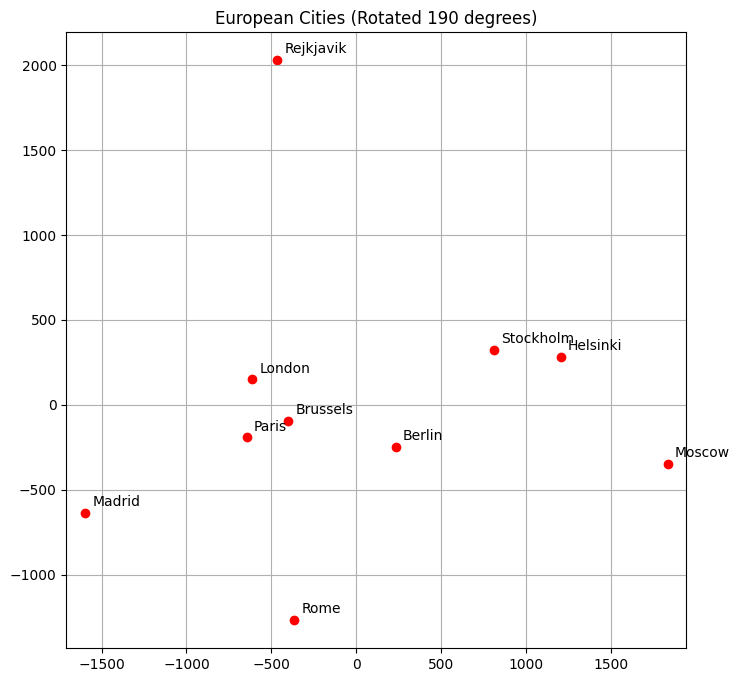

In [2]:
def cmdscale(D, k=2):
    """classicMDS: Projects n points into k-dimensional space."""
    n = D.shape[0]
    H = np.eye(n) - (1/n) * np.ones((n, n))
    B = -0.5 * H @ D @ H
    
    evals, evecs = np.linalg.eigh(B)
    
    # sort
    idx = np.argsort(evals)[::-1]
    evals = evals[idx]
    evecs = evecs[:, idx]
    
    # project
    w_pos = np.maximum(evals, 0)
    Y = evecs @ np.diag(np.sqrt(w_pos))
    return Y[:, :k]

def rotate_data(X, angle_degrees):
    """Rotate 2D data X by angle_degrees (counter-clockwise)"""
    theta = np.radians(angle_degrees)
    c, s = np.cos(theta), np.sin(theta)
    
    # define rotation matrix
    R = np.array([[c, -s], 
                  [s,  c]])
    
    # apply R to every point
    return X @ R.T

# plot
def plot_map(X, labels, title="MDS Map"):
    plt.figure(figsize=(8, 8))
    plt.scatter(X[:, 0], X[:, 1], c='red', marker='o')
    
    for i, txt in enumerate(labels):
        plt.annotate(txt, (X[i, 0], X[i, 1]), 
                     xytext=(5, 5), textcoords='offset points')
        
    plt.title(title)
    plt.grid(True)
    plt.axis('equal')
    plt.savefig("q5b.png")

# get raw MDS coordinates
Y_raw = cmdscale(D_squared)

# rotate
best_angle = 190 
Y_rotated = rotate_data(Y_raw, best_angle)

# call plot_map function
plot_map(Y_rotated, city_names, title=f"European Cities (Rotated {best_angle} degrees)")

/home/scotty/venvs/ucsd/lib/python3.12/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


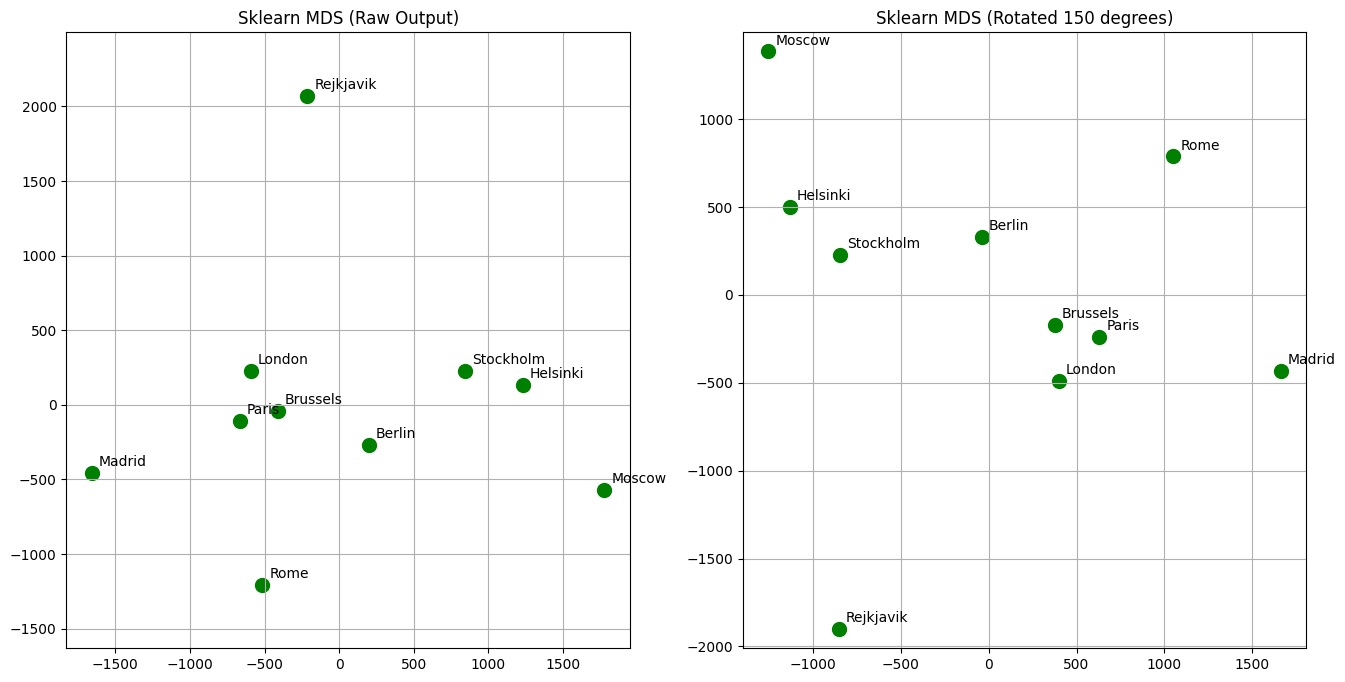

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import MDS

# sklearn MDS
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42, normalized_stress='auto')
Y_sklearn = mds.fit_transform(D) # 

# rotation
def rotate_data(X, angle_degrees):
    theta = np.radians(angle_degrees)
    c, s = np.cos(theta), np.sin(theta)
    R = np.array([[c, -s], [s,  c]])
    return X @ R.T

def plot_embedding(X, title, ax):
    ax.scatter(X[:, 0], X[:, 1], c='green', s=100)
    for i, txt in enumerate(city_names):
        ax.annotate(txt, (X[i, 0], X[i, 1]), xytext=(5, 5), textcoords='offset points')
    ax.set_title(title)
    ax.grid(True)
    ax.axis('equal')

# find correct rotation
angle = 150
Y_rotated = rotate_data(Y_sklearn, angle)

# plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
plot_embedding(Y_sklearn, "Sklearn MDS (Raw Output)", ax1)
plot_embedding(Y_rotated, f"Sklearn MDS (Rotated {angle} degrees)", ax2)

plt.savefig("q5c.png")